# Riskfolio-Lib Tutorial: 
<br><a href="https://www.kqzyfj.com/click-101360347-15150084?url=https%3A%2F%2Flink.springer.com%2Fbook%2F9783031843037" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button.png" height="40" />
</div>
<br>
</a>
<a href="https://www.paypal.com/ncp/payment/GN55W4UQ7VAMN" target="_blank">
<div>
<img src="https://raw.githubusercontent.com/dcajasn/Riskfolio-Lib/refs/heads/master/docs/source/_static/Button2.png" height="40" />
</div>
</a>

<br><a href='https://ko-fi.com/B0B833SXD' target='_blank'><img height='36' style='border:0px;height:36px;' src='https://cdn.ko-fi.com/cdn/kofi1.png?v=2' border='0' alt='Buy Me a Coffee at ko-fi.com' /></a> 
<br>
<br>__[Financionerioncios](https://financioneroncios.wordpress.com)__
<br>__[Orenji](https://www.linkedin.com/company/orenj-i)__
<br>__[Riskfolio-Lib](https://portfoliooptimization.org)__
<br>__[Dany Cajas](https://www.linkedin.com/in/dany-cajas/)__
## Tutorial 33: Comparing Covariance Estimators Methods

## 1. Downloading the data:

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings

warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

# Date range
start = '2016-01-01'
end = '2019-12-30'

# Tickers of assets
assets = ['JCI', 'TGT', 'CMCSA', 'CPB', 'MO', 'APA', 'MRSH', 'JPM',
          'ZION', 'PSA', 'BAX', 'BMY', 'LUV', 'PCAR', 'TXT', 'TMO',
          'DE', 'MSFT', 'HPQ', 'SHW', 'VZ', 'CNP', 'NI', 'T', 'BA']
assets.sort()

# Downloading data
data = yf.download(assets, start = start, end = end, auto_adjust=False)
data = data.loc[:,('Adj Close', slice(None))]
data.columns = assets

[*********************100%***********************]  25 of 25 completed


In [2]:
# Calculating returns

Y = data[assets].pct_change().dropna()

display(Y.head())

,APA,BA,BAX,BMY,CMCSA,CNP,CPB,DE,HPQ,JCI,...,NI,PCAR,PSA,SHW,T,TGT,TMO,TXT,VZ,ZION
Date,,,,,,,,,,,,,,,,,,,,,
2016-01-05,-2.0256%,0.4057%,0.4035%,1.9693%,0.0179%,0.9305%,0.3678%,0.5783%,0.9482%,-1.1953%,...,1.5881%,0.0212%,2.8236%,0.4043%,0.6987%,1.7539%,-0.1730%,0.2409%,1.3734%,-1.0857%
2016-01-06,-11.4863%,-1.5878%,0.2411%,-1.7557%,-0.7727%,-1.2473%,-0.1735%,-1.1239%,-3.5866%,-0.9551%,...,0.5547%,0.0212%,0.1592%,-2.8931%,0.3108%,-1.0155%,-0.7653%,-3.0048%,-0.9034%,-2.9145%
2016-01-07,-5.1389%,-4.1922%,-1.6573%,-2.7699%,-1.1047%,-1.9769%,-1.2207%,-0.8856%,-4.6058%,-2.5394%,...,-2.2066%,-3.0309%,-1.0410%,-2.7418%,-1.6148%,-0.2699%,-2.2845%,-2.0570%,-0.5492%,-3.0019%
2016-01-08,0.2737%,-2.2705%,-1.6037%,-2.5425%,0.1099%,-0.2241%,0.5706%,-1.6402%,-1.7642%,-0.1649%,...,-0.1538%,-1.1366%,-0.7308%,0.0828%,0.0895%,-3.3839%,-0.1117%,-1.1387%,-0.9719%,-1.1254%
2016-01-11,-4.3383%,0.1692%,-1.6851%,-1.0215%,0.0915%,-1.1791%,0.5674%,0.5288%,0.6617%,0.0330%,...,1.6436%,0.0000%,0.9869%,0.0828%,1.2224%,1.4570%,0.5367%,-0.4607%,0.5800%,-1.9919%


## 2. Estimating Mean Variance Portfolios

### 2.1 Calculating the portfolio that minimizes Variance.

In [3]:
import riskfolio as rp

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimal portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_covs = ['hist', 'ledoit', 'oas', 'shrunk', 'gl', 'ewma1',
               'ewma2','jlogo', 'fixed', 'spectral', 'shrink',
               'gerber1', 'gerber2']

# Estimate optimal portfolio:

model='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = 'MV' # Risk measure used, this time will be variance
obj = 'MinRisk' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

w_s = pd.DataFrame([])

for i in method_covs:
    port.assets_stats(method_mu=method_mu, method_cov=i)
    w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)
    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = method_covs

In [4]:
display(w_s.style.format("{:.2%}").background_gradient(cmap='YlGn'))

,hist,ledoit,oas,shrunk,gl,ewma1,ewma2,jlogo,fixed,spectral,shrink,gerber1,gerber2
APA,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.04%,0.00%
BA,0.00%,0.00%,0.00%,0.13%,1.21%,6.57%,6.57%,3.06%,0.00%,0.00%,0.00%,1.02%,0.00%
BAX,5.01%,5.12%,5.08%,5.35%,6.30%,3.62%,3.62%,8.72%,3.93%,0.00%,3.25%,5.48%,6.19%
BMY,4.37%,4.44%,4.41%,4.64%,4.13%,7.59%,7.59%,5.18%,2.08%,0.00%,3.99%,2.91%,2.34%
CMCSA,2.00%,2.20%,2.12%,2.79%,4.01%,5.35%,5.35%,2.48%,0.87%,0.00%,0.96%,3.92%,3.75%
CNP,6.91%,7.04%,6.99%,7.33%,9.59%,4.15%,4.15%,6.62%,7.43%,0.00%,5.14%,7.82%,7.64%
CPB,3.20%,3.35%,3.29%,3.87%,4.63%,5.96%,5.96%,6.07%,1.68%,0.00%,1.96%,2.43%,0.45%
DE,0.00%,0.00%,0.00%,0.39%,0.04%,4.43%,4.43%,1.25%,0.00%,0.00%,0.00%,0.39%,0.00%
HPQ,0.00%,0.00%,0.00%,0.00%,0.00%,2.18%,2.18%,0.20%,0.00%,0.00%,0.00%,0.00%,0.00%
JCI,2.66%,2.76%,2.72%,3.03%,3.63%,2.34%,2.34%,4.78%,1.43%,0.00%,2.27%,2.00%,1.22%


<Axes: >

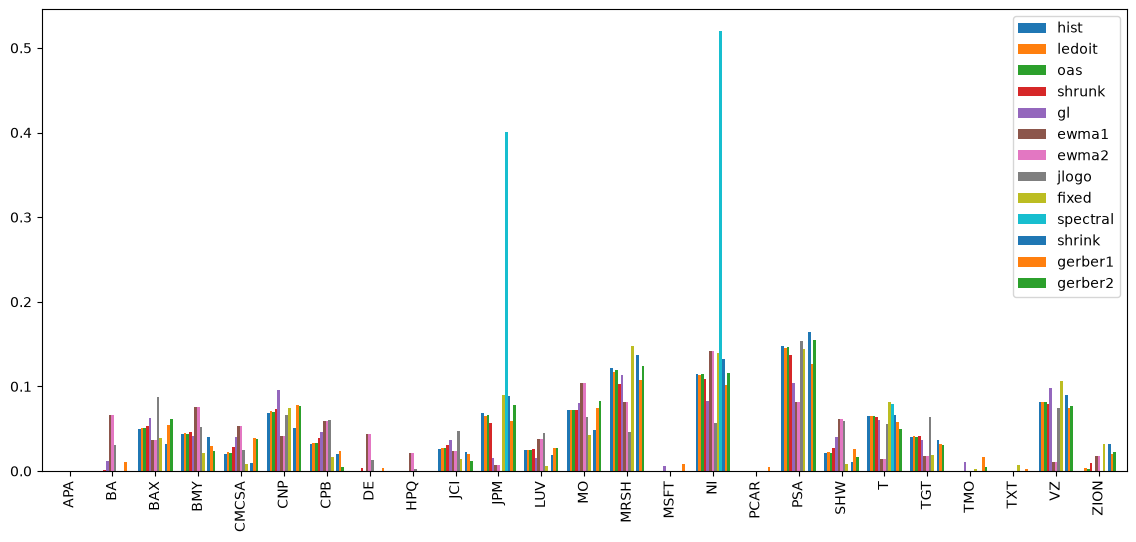

In [5]:
import matplotlib.pyplot as plt

# Plotting a comparison of assets weights for each portfolio
fig, ax = plt.subplots(figsize=(14,6))

w_s.plot.bar(ax=ax, width=0.8)

### 2.2 Calculating the portfolio that maximizes Sharpe ratio.

In [6]:
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe

w_s = pd.DataFrame([])

for i in method_covs:
    port.assets_stats(method_mu=method_mu, method_cov=i)
    w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)
    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = method_covs

In [7]:
display(w_s.style.format("{:.2%}").background_gradient(cmap='YlGn'))

,hist,ledoit,oas,shrunk,gl,ewma1,ewma2,jlogo,fixed,spectral,shrink,gerber1,gerber2
APA,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
BA,5.52%,5.64%,5.59%,6.07%,3.86%,7.46%,7.46%,9.60%,3.54%,0.00%,4.41%,6.21%,6.21%
BAX,10.29%,10.39%,10.35%,10.61%,9.81%,7.48%,7.48%,11.80%,9.79%,0.00%,9.70%,9.31%,9.18%
BMY,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
CMCSA,0.00%,0.00%,0.00%,0.00%,2.81%,0.44%,0.44%,0.00%,0.00%,0.00%,0.00%,0.54%,0.00%
CNP,7.84%,7.93%,7.90%,8.14%,11.35%,6.56%,6.56%,11.84%,6.35%,0.00%,5.08%,8.37%,8.26%
CPB,0.00%,0.00%,0.00%,0.00%,1.17%,1.35%,1.35%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
DE,2.65%,2.86%,2.77%,3.58%,2.26%,4.93%,4.93%,5.87%,2.25%,0.00%,2.40%,4.57%,3.35%
HPQ,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
JCI,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


<Axes: >

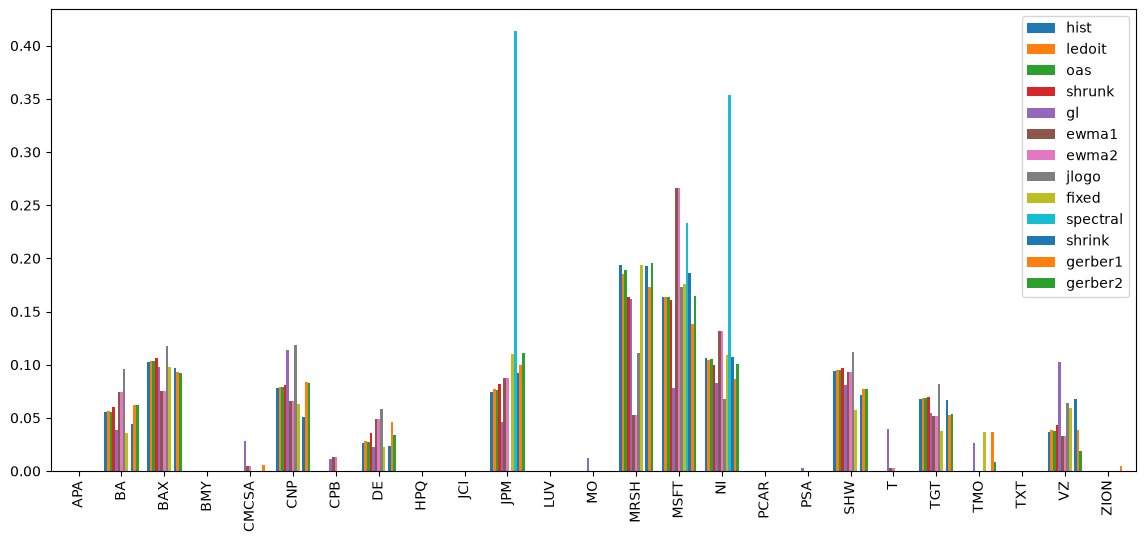

In [8]:
# Plotting a comparison of assets weights for each portfolio
ax, fig = plt.subplots(figsize=(14,6))

w_s.plot.bar(ax=fig, width=0.8)